In [1]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Path to Notebook 01 outputs
DATA_DIR = Path('/content/drive/MyDrive/PathoScope/data')

# Check files
print("Checking Notebook 01 outputs...\n")

for filename in ["tiles_img.zip", "tiles_mask.zip", "tiles.csv"]:
    path = DATA_DIR / filename

    if path.exists():
        print(f"FOUND: {filename} ({path.stat().st_size / 1024**2:.2f} MB)")
    else:
        print(f"MISSING: {filename}")

print("\nDATA_DIR =", DATA_DIR)

Mounted at /content/drive
Checking Notebook 01 outputs...

FOUND: tiles_img.zip (339.33 MB)
FOUND: tiles_mask.zip (6.17 MB)
FOUND: tiles.csv (2.85 MB)

DATA_DIR = /content/drive/MyDrive/PathoScope/data


In [2]:
import pandas as pd

csv_path = DATA_DIR / "tiles.csv"

tiles_df = pd.read_csv(csv_path)

print("=" * 60)
print("PathoScope Notebook 02 — Input Check")
print("=" * 60)

print("\nShape:", tiles_df.shape)

print("\nColumns:")
print(tiles_df.columns.tolist())

print("\nFirst 5 rows:")
display(tiles_df.head())

print("\nTile label distribution:")
print(tiles_df["tile_label"].value_counts().sort_index())

print("\nProvider distribution:")
print(tiles_df["data_provider"].value_counts())

print("\nISUP distribution:")
print(tiles_df["isup_grade"].value_counts().sort_index())

PathoScope Notebook 02 — Input Check

Shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

First 5 rows:


,tile_id,image_id,data_provider,x,y,tile_size,tissue_fraction,tile_label,isup_grade,gleason_score,mask_available,image_path,mask_path
0,8f264374ed3fa427615c1650218e7f21_x1536_y1536,8f264374ed3fa427615c1650218e7f21,radboud,1536,1536,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1536_...,masks/8f264374ed3fa427615c1650218e7f21_x1536_y...
1,8f264374ed3fa427615c1650218e7f21_x1792_y4864,8f264374ed3fa427615c1650218e7f21,radboud,1792,4864,256,1.0,1,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1792_...,masks/8f264374ed3fa427615c1650218e7f21_x1792_y...
2,8f264374ed3fa427615c1650218e7f21_x2560_y7936,8f264374ed3fa427615c1650218e7f21,radboud,2560,7936,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...
3,8f264374ed3fa427615c1650218e7f21_x2048_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2048,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2048_...,masks/8f264374ed3fa427615c1650218e7f21_x2048_y...
4,8f264374ed3fa427615c1650218e7f21_x2560_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2560,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...



Tile label distribution:
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64

Provider distribution:
data_provider
radboud       6400
karolinska    6400
Name: count, dtype: int64

ISUP distribution:
isup_grade
0    3520
1    3200
2    1600
3    1472
4    1536
5    1472
Name: count, dtype: int64


In [3]:
import zipfile
from pathlib import Path
import time

# Local Colab working directory
WORK_DIR = Path("/content/pathoscope_02")
IMG_DIR = WORK_DIR / "images"
MASK_DIR = WORK_DIR / "masks"

WORK_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

img_zip = DATA_DIR / "tiles_img.zip"
mask_zip = DATA_DIR / "tiles_mask.zip"

print("=" * 60)
print("PathoScope Notebook 02 — Extracting tile data")
print("=" * 60)

# Extract images
print("\nExtracting images...")
start = time.time()

with zipfile.ZipFile(img_zip, "r") as z:
    z.extractall(IMG_DIR)

print(f"Images extracted in {time.time() - start:.1f} seconds")

# Extract masks
print("\nExtracting masks...")
start = time.time()

with zipfile.ZipFile(mask_zip, "r") as z:
    z.extractall(MASK_DIR)

print(f"Masks extracted in {time.time() - start:.1f} seconds")

# Count files
image_files = list(IMG_DIR.rglob("*.jpg"))
mask_files = list(MASK_DIR.rglob("*.png"))

print("\n" + "=" * 60)
print("EXTRACTION CHECK")
print("=" * 60)

print("Images:", len(image_files))
print("Masks :", len(mask_files))
print("Expected images:", len(tiles_df))
print("Expected masks :", len(tiles_df))

if len(image_files) == len(tiles_df):
    print("\nIMAGE CHECK: PASSED")
else:
    print("\nIMAGE CHECK: CHECK REQUIRED")

if len(mask_files) == len(tiles_df):
    print("MASK CHECK: PASSED")
else:
    print("MASK CHECK: CHECK REQUIRED")

PathoScope Notebook 02 — Extracting tile data

Extracting images...
Images extracted in 10.1 seconds

Extracting masks...
Masks extracted in 3.3 seconds

EXTRACTION CHECK
Images: 12800
Masks : 12800
Expected images: 12800
Expected masks : 12800

IMAGE CHECK: PASSED
MASK CHECK: PASSED


In [4]:
from PIL import Image
import numpy as np

print("=" * 60)
print("PathoScope Notebook 02 — Tile Read Test")
print("=" * 60)

# Pick first image and mask
sample_image = sorted(IMG_DIR.rglob("*.jpg"))[0]
sample_mask = sorted(MASK_DIR.rglob("*.png"))[0]

print("\nSample image:")
print(sample_image)

print("\nSample mask:")
print(sample_mask)

# Read image
img = Image.open(sample_image).convert("RGB")
img_array = np.array(img)

# Read mask
mask = Image.open(sample_mask)
mask_array = np.array(mask)

print("\nImage:")
print("  Size :", img.size)
print("  Shape:", img_array.shape)
print("  Dtype:", img_array.dtype)

print("\nMask:")
print("  Size :", mask.size)
print("  Shape:", mask_array.shape)
print("  Dtype:", mask_array.dtype)

print("\nImage pixel range:",
      img_array.min(), "to", img_array.max())

print("Mask unique values:",
      np.unique(mask_array)[:20])

# Validate expected tile size
if img.size == (256, 256):
    print("\nIMAGE SIZE CHECK: PASSED")
else:
    print("\nIMAGE SIZE CHECK: CHECK REQUIRED")

PathoScope Notebook 02 — Tile Read Test

Sample image:
/content/pathoscope_02/images/008069b542b0439ed69b194674051964_x10240_y2048.jpg

Sample mask:
/content/pathoscope_02/masks/008069b542b0439ed69b194674051964_x10240_y2048.png

Image:
  Size : (256, 256)
  Shape: (256, 256, 3)
  Dtype: uint8

Mask:
  Size : (256, 256)
  Shape: (256, 256)
  Dtype: uint8

Image pixel range: 17 to 255
Mask unique values: [1 2]

IMAGE SIZE CHECK: PASSED


In [5]:
import numpy as np
import cv2
from pathlib import Path

print("=" * 60)
print("PathoScope Notebook 02 — Macenko Setup")
print("=" * 60)

# ---------------------------------------------------------
# Macenko parameters
# ---------------------------------------------------------

IOD_EPS = 1e-6
OD_THRESHOLD = 0.15
PERCENTILE_LOW = 1
PERCENTILE_HIGH = 99

print("\nParameters:")
print("OD threshold:", OD_THRESHOLD)
print("Low percentile:", PERCENTILE_LOW)
print("High percentile:", PERCENTILE_HIGH)

# ---------------------------------------------------------
# Read sample tile
# ---------------------------------------------------------

sample_path = sorted(IMG_DIR.rglob("*.jpg"))[0]

tile = cv2.imread(str(sample_path))

if tile is None:
    raise RuntimeError(f"Could not read image: {sample_path}")

# OpenCV BGR → RGB
tile_rgb = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)

print("\nSample tile:")
print("Path :", sample_path)
print("Shape:", tile_rgb.shape)
print("Dtype:", tile_rgb.dtype)


# RGB → Optical Density


rgb = tile_rgb.astype(np.float32) / 255.0

rgb = np.clip(rgb, IOD_EPS, 1.0)

od = -np.log(rgb)

print("\nOptical Density:")
print("Shape:", od.shape)
print("Min  :", od.min())
print("Max  :", od.max())


# Select informative pixels


od_2d = od.reshape(-1, 3)

od_norm = np.linalg.norm(od_2d, axis=1)

informative = od_norm > OD_THRESHOLD

od_selected = od_2d[informative]

print("\nInformative pixels:")
print("Total pixels:", len(od_2d))
print("Selected    :", len(od_selected))
print("Percentage  :",
      100 * len(od_selected) / len(od_2d))

if len(od_selected) == 0:
    raise RuntimeError("No informative pixels found.")

print("\nMACENKO SETUP CHECK: PASSED")

PathoScope Notebook 02 — Macenko Setup

Parameters:
OD threshold: 0.15
Low percentile: 1
High percentile: 99

Sample tile:
Path : /content/pathoscope_02/images/008069b542b0439ed69b194674051964_x10240_y2048.jpg
Shape: (256, 256, 3)
Dtype: uint8

Optical Density:
Shape: (256, 256, 3)
Min  : -0.0
Max  : 2.7080503

Informative pixels:
Total pixels: 65536
Selected    : 64891
Percentage  : 99.01580810546875

MACENKO SETUP CHECK: PASSED


In [6]:

# PathoScope Notebook 02 — Macenko Stain Vector Estimation


import numpy as np

print("=" * 60)
print("Macenko — Stain Vector Estimation")
print("=" * 60)

# Use the informative OD pixels from the previous cell
X = od_selected.astype(np.float32)


# 1. Compute covariance matrix


cov_matrix = np.cov(X, rowvar=False)

print("\nCovariance matrix:")
print(cov_matrix)


# 2. Eigen decomposition

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvectors by descending eigenvalue
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues:")
print(eigenvalues)

# First two principal directions
v1 = eigenvectors[:, 0]
v2 = eigenvectors[:, 1]

print("\nPrincipal direction 1:")
print(v1)

print("\nPrincipal direction 2:")
print(v2)


# 3. Project OD values onto first two eigenvectors


projection = X @ np.column_stack([v1, v2])

angles = np.arctan2(
    projection[:, 1],
    projection[:, 0]
)


# 4. Find angular percentiles


min_angle = np.percentile(
    angles,
    PERCENTILE_LOW
)

max_angle = np.percentile(
    angles,
    PERCENTILE_HIGH
)

print("\nAngular range:")
print("Low :", min_angle)
print("High:", max_angle)


# 5. Estimate two stain directions

stain1 = (
    np.cos(min_angle) * v1 +
    np.sin(min_angle) * v2
)

stain2 = (
    np.cos(max_angle) * v1 +
    np.sin(max_angle) * v2
)

# Normalize vectors
stain1 = stain1 / np.linalg.norm(stain1)
stain2 = stain2 / np.linalg.norm(stain2)

stain_matrix = np.column_stack([
    stain1,
    stain2
])

print("\nEstimated stain matrix:")
print(stain_matrix)

print("\nStain vector norms:")
print(np.linalg.norm(stain1))
print(np.linalg.norm(stain2))

print("\nSTAIN VECTOR ESTIMATION: PASSED")

Macenko — Stain Vector Estimation

Covariance matrix:
[[0.03301046 0.0413017  0.02716329]
 [0.0413017  0.05936004 0.03884999]
 [0.02716329 0.03884999 0.02587317]]

Eigenvalues:
[0.11479899 0.00313252 0.00031216]

Principal direction 1:
[-0.51726616 -0.71497775 -0.47036426]

Principal direction 2:
[-0.85582133  0.43062028  0.28659382]

Angular range:
Low : 2.6154158977713395
High: 3.1000909705616584

Estimated stain matrix:
[[0.01747745 0.48131292]
 [0.83453607 0.73222844]
 [0.55067603 0.48184995]]

Stain vector norms:
1.0
1.0

STAIN VECTOR ESTIMATION: PASSED


Macenko — Single Tile Normalization

Original shape : (256, 256, 3)
Normalized shape: (256, 256, 3)
Original range: 17.0 to 255.0
Normalized range: 54 to 254

MACENKO SINGLE-TILE NORMALIZATION: PASSED


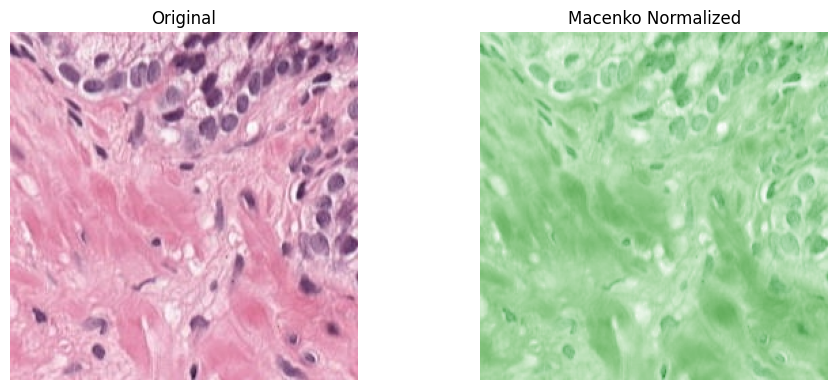

In [7]:

# PathoScope Notebook 02 — Macenko Normalization Test


import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 60)
print("Macenko — Single Tile Normalization")
print("=" * 60)


# Reference stain matrix


target_stains = np.array([
    [0.650, 0.704],
    [0.268, 0.286],
    [0.711, 0.650]
], dtype=np.float32)

# Normalize target stain vectors
target_stains /= np.linalg.norm(
    target_stains,
    axis=0,
    keepdims=True
)


# Use the sample tile


sample_path = sorted(IMG_DIR.rglob("*.jpg"))[0]

rgb_img = np.array(
    Image.open(sample_path).convert("RGB")
).astype(np.float32)


# RGB → Optical Density


rgb = np.clip(
    rgb_img / 255.0,
    1e-6,
    1.0
)

od_img = -np.log(rgb)

od_flat = od_img.reshape(-1, 3)

# Estimate stain concentrations


# Pseudo-inverse of estimated stain matrix
stain_inv = np.linalg.pinv(
    stain_matrix.astype(np.float32)
)

concentrations = od_flat @ stain_inv.T

# Prevent negative concentrations
concentrations = np.maximum(
    concentrations,
    0
)

# Robust concentration scaling


max_conc = np.percentile(
    concentrations,
    99,
    axis=0
)

max_conc = np.maximum(
    max_conc,
    1e-6
)


# Reconstruct normalized OD


normalized_conc = (
    concentrations / max_conc
)

normalized_od = (
    normalized_conc @ target_stains.T
)


# OD → RGB


normalized_rgb = np.exp(
    -normalized_od
)

normalized_rgb = np.clip(
    normalized_rgb * 255.0,
    0,
    255
).astype(np.uint8)

normalized_rgb = normalized_rgb.reshape(
    rgb_img.shape
)

print("\nOriginal shape :", rgb_img.shape)
print("Normalized shape:", normalized_rgb.shape)

print(
    "Original range:",
    rgb_img.min(),
    "to",
    rgb_img.max()
)

print(
    "Normalized range:",
    normalized_rgb.min(),
    "to",
    normalized_rgb.max()
)

print("\nMACENKO SINGLE-TILE NORMALIZATION: PASSED")


# Display comparison


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img.astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normalized_rgb)
plt.title("Macenko Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

Original shape: (256, 256, 3)
Normalized shape: (256, 256, 3)
Normalized range: 56 to 254


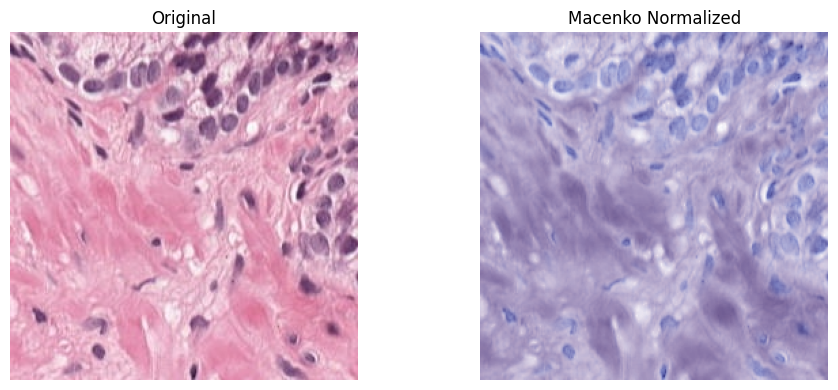

In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Reference stain values
target_stains = np.array([
    [0.5626, 0.7201],
    [0.7201, 0.6800],
    [0.4062, 0.2753]
], dtype=np.float32)

target_stains /= np.linalg.norm(
    target_stains,
    axis=0,
    keepdims=True
)

# Load one tile
sample_path = sorted(IMG_DIR.rglob("*.jpg"))[0]

rgb_img = np.array(
    Image.open(sample_path).convert("RGB")
).astype(np.float32)

# Convert RGB to optical density
rgb = np.clip(rgb_img / 255.0, 1e-6, 1.0)
od_img = -np.log(rgb)

od_flat = od_img.reshape(-1, 3)

# Estimate stain concentrations
stain_inv = np.linalg.pinv(
    stain_matrix.astype(np.float32)
)

concentrations = od_flat @ stain_inv.T
concentrations = np.maximum(concentrations, 0)

# Scale the stain concentrations
max_conc = np.percentile(
    concentrations,
    99,
    axis=0
)

max_conc = np.maximum(max_conc, 1e-6)

normalized_conc = concentrations / max_conc

# Reconstruct the normalized image
normalized_od = normalized_conc @ target_stains.T

normalized_rgb = np.exp(-normalized_od)
normalized_rgb = np.clip(
    normalized_rgb * 255.0,
    0,
    255
).astype(np.uint8)

normalized_rgb = normalized_rgb.reshape(rgb_img.shape)

print("Original shape:", rgb_img.shape)
print("Normalized shape:", normalized_rgb.shape)
print("Normalized range:", normalized_rgb.min(), "to", normalized_rgb.max())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img.astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normalized_rgb)
plt.title("Macenko Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

Original shape: (256, 256, 3)
Normalized shape: (256, 256, 3)
Normalized range: 9 to 255

Estimated stain matrix:
[[0.48063502 0.24720276]
 [0.74559847 0.81461669]
 [0.4615982  0.52468128]]


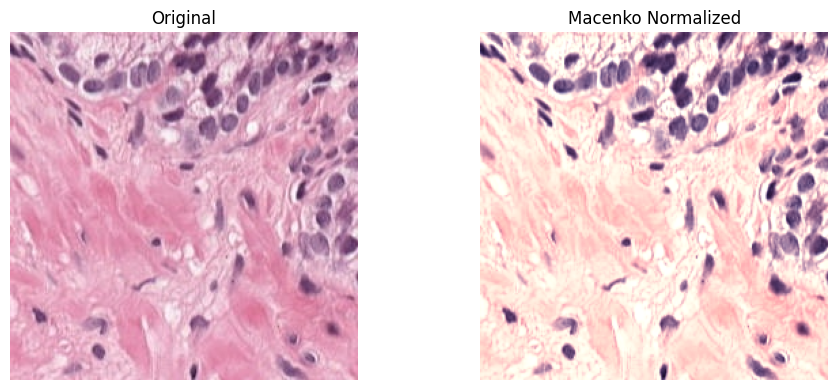

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

HE_REF = np.array([
    [0.5626, 0.2159],
    [0.7201, 0.8012],
    [0.4062, 0.5581]
], dtype=np.float32)

MAX_C_REF = np.array([1.9705, 1.0308], dtype=np.float32)

def standardize_brightness(img):
    p = np.percentile(img, 90)
    return np.clip(img * 255.0 / max(p, 1.0), 0, 255).astype(np.uint8)

def get_stain_matrix(img, beta=0.15, alpha=1.0, Io=240):
    img = standardize_brightness(img)

    img_float = img.astype(np.float32)

    od = -np.log((img_float + 1.0) / Io)
    od = od.reshape(-1, 3)

    od_tissue = od[~np.any(od < beta, axis=1)]

    eigvals, eigvecs = np.linalg.eigh(
        np.cov(od_tissue, rowvar=False)
    )

    eigvecs = eigvecs[:, [2, 1]]

    if eigvecs[0, 0] < 0:
        eigvecs[:, 0] *= -1

    if eigvecs[0, 1] < 0:
        eigvecs[:, 1] *= -1

    projected = od_tissue @ eigvecs

    angles = np.arctan2(
        projected[:, 1],
        projected[:, 0]
    )

    min_angle = np.percentile(
        angles,
        alpha
    )

    max_angle = np.percentile(
        angles,
        100 - alpha
    )

    v_min = eigvecs @ np.array([
        np.cos(min_angle),
        np.sin(min_angle)
    ])

    v_max = eigvecs @ np.array([
        np.cos(max_angle),
        np.sin(max_angle)
    ])

    if v_min[0] > v_max[0]:
        stain_matrix = np.column_stack([
            v_min,
            v_max
        ])
    else:
        stain_matrix = np.column_stack([
            v_max,
            v_min
        ])

    stain_matrix /= np.linalg.norm(
        stain_matrix,
        axis=0,
        keepdims=True
    )

    return stain_matrix, img

def macenko_normalize(img):
    stain_matrix, img = get_stain_matrix(img)

    Io = 240.0

    od = -np.log(
        (img.astype(np.float32) + 1.0) / Io
    )

    h, w, _ = img.shape

    Y = od.reshape(-1, 3).T

    concentrations = np.linalg.lstsq(
        stain_matrix,
        Y,
        rcond=None
    )[0]

    max_c = np.percentile(
        concentrations,
        99,
        axis=1
    )

    max_c = np.maximum(max_c, 1e-6)

    scale = max_c / MAX_C_REF

    normalized_c = concentrations / scale[:, None]

    normalized = Io * np.exp(
        -HE_REF @ normalized_c
    )

    normalized = np.clip(
        normalized,
        0,
        255
    )

    normalized = normalized.T.reshape(
        h,
        w,
        3
    ).astype(np.uint8)

    return normalized, stain_matrix

sample_path = sorted(IMG_DIR.rglob("*.jpg"))[0]

original = np.array(
    Image.open(sample_path).convert("RGB")
)

normalized, estimated_matrix = macenko_normalize(
    original
)

print("Original shape:", original.shape)
print("Normalized shape:", normalized.shape)
print("Normalized range:", normalized.min(), "to", normalized.max())

print("\nEstimated stain matrix:")
print(estimated_matrix)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normalized)
plt.title("Macenko Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from pathlib import Path
import numpy as np

REF_DIR = Path("/content/pathoscope_02")
REF_FILE = REF_DIR / "ref_stain.npz"

np.savez(
    REF_FILE,
    HE_REF=HE_REF,
    MAX_C_REF=MAX_C_REF
)

print("Reference stain file created:")
print(REF_FILE)
print("HE_REF shape:", HE_REF.shape)
print("MAX_C_REF:", MAX_C_REF)

print("\nFile exists:", REF_FILE.exists())
print("File size:", REF_FILE.stat().st_size, "bytes")

Reference stain file created:
/content/pathoscope_02/ref_stain.npz
HE_REF shape: (3, 2)
MAX_C_REF: [1.9705 1.0308]

File exists: True
File size: 548 bytes


In [11]:
from pathlib import Path
import numpy as np
from PIL import Image
import zipfile
import time

# Load reference stain
ref_data = np.load(REF_FILE)
HE_REF = ref_data["HE_REF"]
MAX_C_REF = ref_data["MAX_C_REF"]

NORM_DIR = WORK_DIR / "tiles_norm"
NORM_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted(IMG_DIR.rglob("*.jpg"))

print("Input tiles:", len(image_files))
print("Output directory:", NORM_DIR)

start_time = time.time()
processed = 0
skipped = 0
failed = []

for i, img_path in enumerate(image_files, start=1):
    output_path = NORM_DIR / img_path.name

    # Skip tiles that are already processed
    if output_path.exists():
        skipped += 1
        continue

    try:
        img = np.array(Image.open(img_path).convert("RGB"))

        normalized, _ = macenko_normalize(img)

        Image.fromarray(normalized).save(
            output_path,
            format="JPEG",
            quality=95
        )

        processed += 1

    except Exception as e:
        failed.append((img_path.name, str(e)))

    if i % 250 == 0 or i == len(image_files):
        elapsed = time.time() - start_time
        print(
            f"{i}/{len(image_files)} | "
            f"processed={processed} | "
            f"skipped={skipped} | "
            f"failed={len(failed)} | "
            f"time={elapsed/60:.1f} min"
        )

print("\nNormalization finished.")
print("Processed:", processed)
print("Skipped:", skipped)
print("Failed:", len(failed))

Input tiles: 12800
Output directory: /content/pathoscope_02/tiles_norm
250/12800 | processed=250 | skipped=0 | failed=0 | time=0.1 min


/tmp/ipykernel_1494/1264688227.py:116: RuntimeWarning: overflow encountered in exp
  normalized = Io * np.exp(


500/12800 | processed=500 | skipped=0 | failed=0 | time=0.2 min


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipykernel_1494/1264688227.py:28: RuntimeWarning: Degrees of freedom <= 0 for slice
  np.cov(od_tissue, rowvar=False)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


750/12800 | processed=745 | skipped=0 | failed=5 | time=0.3 min
1000/12800 | processed=980 | skipped=0 | failed=20 | time=0.5 min


/tmp/ipykernel_1494/1264688227.py:116: RuntimeWarning: overflow encountered in multiply
  normalized = Io * np.exp(


1250/12800 | processed=1220 | skipped=0 | failed=30 | time=0.5 min
1500/12800 | processed=1470 | skipped=0 | failed=30 | time=0.7 min
1750/12800 | processed=1715 | skipped=0 | failed=35 | time=0.8 min
2000/12800 | processed=1957 | skipped=0 | failed=43 | time=0.9 min
2250/12800 | processed=2207 | skipped=0 | failed=43 | time=1.0 min
2500/12800 | processed=2407 | skipped=0 | failed=93 | time=1.1 min
2750/12800 | processed=2657 | skipped=0 | failed=93 | time=1.2 min
3000/12800 | processed=2906 | skipped=0 | failed=94 | time=1.3 min
3250/12800 | processed=3156 | skipped=0 | failed=94 | time=1.5 min
3500/12800 | processed=3406 | skipped=0 | failed=94 | time=1.5 min
3750/12800 | processed=3656 | skipped=0 | failed=94 | time=1.7 min
4000/12800 | processed=3877 | skipped=0 | failed=123 | time=1.8 min
4250/12800 | processed=4125 | skipped=0 | failed=125 | time=1.9 min
4500/12800 | processed=4375 | skipped=0 | failed=125 | time=2.0 min
4750/12800 | processed=4625 | skipped=0 | failed=125 | time

In [12]:
print("Number of failed tiles:", len(failed))

print("\nFirst 20 failures:")
for name, error in failed[:20]:
    print(name, "->", error)

print("\nNormalized files currently:", len(list(NORM_DIR.glob("*.jpg"))))
print("Expected files:", len(image_files))

Number of failed tiles: 134

First 20 failures:
08e90c44bcfe29aa64beff429f94e291_x4608_y9216.jpg -> Eigenvalues did not converge
08e90c44bcfe29aa64beff429f94e291_x4608_y9472.jpg -> Eigenvalues did not converge
08e90c44bcfe29aa64beff429f94e291_x6144_y10496.jpg -> Eigenvalues did not converge
08e90c44bcfe29aa64beff429f94e291_x9216_y5632.jpg -> Eigenvalues did not converge
08e90c44bcfe29aa64beff429f94e291_x9472_y5120.jpg -> 0-dimensional array given. Array must be at least two-dimensional
0f1ea91c9f917bb3d198f02fd432e4ce_x0_y0.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x0_y256.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x1024_y0.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x1280_y0.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x1536_y0.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x1792_y0.jpg -> Eigenvalues did not converge
0f1ea91c9f917bb3d198f02fd432e4ce_x2048_y0.jpg

In [13]:
failed_names = {name for name, _ in failed}

failed_rows = tiles_df[
    tiles_df["image_path"].apply(lambda x: Path(x).name in failed_names)
].copy()

print("Failed tile rows:", len(failed_rows))

print("\nFailed tile labels:")
print(failed_rows["tile_label"].value_counts(dropna=False))

print("\nFailed tissue fraction:")
print(failed_rows["tissue_fraction"].describe())

print("\nFailed ISUP grades:")
print(failed_rows["isup_grade"].value_counts().sort_index())

Failed tile rows: 134

Failed tile labels:
tile_label
 0    83
-1    51
Name: count, dtype: int64

Failed tissue fraction:
count    134.000000
mean       0.874825
std        0.329451
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: tissue_fraction, dtype: float64

Failed ISUP grades:
isup_grade
0     15
1      5
2    104
4      4
5      6
Name: count, dtype: int64


In [14]:
from PIL import Image
import numpy as np

recovered = 0
recovery_failed = []

for name, error in failed:
    input_path = IMG_DIR / name
    output_path = NORM_DIR / name

    try:
        img = Image.open(input_path).convert("RGB")
        img.save(output_path, format="JPEG", quality=95)
        recovered += 1

    except Exception as e:
        recovery_failed.append((name, str(e)))

print("Failed tiles originally:", len(failed))
print("Recovered:", recovered)
print("Recovery failures:", len(recovery_failed))

print("\nNormalized files:", len(list(NORM_DIR.glob("*.jpg"))))
print("Expected files:", len(image_files))

if recovery_failed:
    print("\nRecovery errors:")
    for item in recovery_failed[:10]:
        print(item)

Failed tiles originally: 134
Recovered: 134
Recovery failures: 0

Normalized files: 12800
Expected files: 12800


In [15]:
from pathlib import Path
from PIL import Image
import numpy as np

input_files = sorted(IMG_DIR.glob("*.jpg"))
norm_files = sorted(NORM_DIR.glob("*.jpg"))

input_names = {p.name for p in input_files}
norm_names = {p.name for p in norm_files}

missing_norm = sorted(input_names - norm_names)
extra_norm = sorted(norm_names - input_names)

bad_files = []

for path in norm_files:
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        bad_files.append((path.name, str(e)))

print("Input tiles:", len(input_files))
print("Normalized tiles:", len(norm_files))
print("Missing normalized:", len(missing_norm))
print("Extra normalized:", len(extra_norm))
print("Corrupt normalized:", len(bad_files))

if missing_norm:
    print("\nMissing examples:")
    print(missing_norm[:10])

if extra_norm:
    print("\nExtra examples:")
    print(extra_norm[:10])

if bad_files:
    print("\nCorrupt examples:")
    print(bad_files[:10])

if (
    len(input_files) == 12800
    and len(norm_files) == 12800
    and len(missing_norm) == 0
    and len(extra_norm) == 0
    and len(bad_files) == 0
):
    print("\nFINAL TILE VALIDATION PASSED")
else:
    print("\nFINAL TILE VALIDATION FAILED")

Input tiles: 12800
Normalized tiles: 12800
Missing normalized: 0
Extra normalized: 0
Corrupt normalized: 0

FINAL TILE VALIDATION PASSED


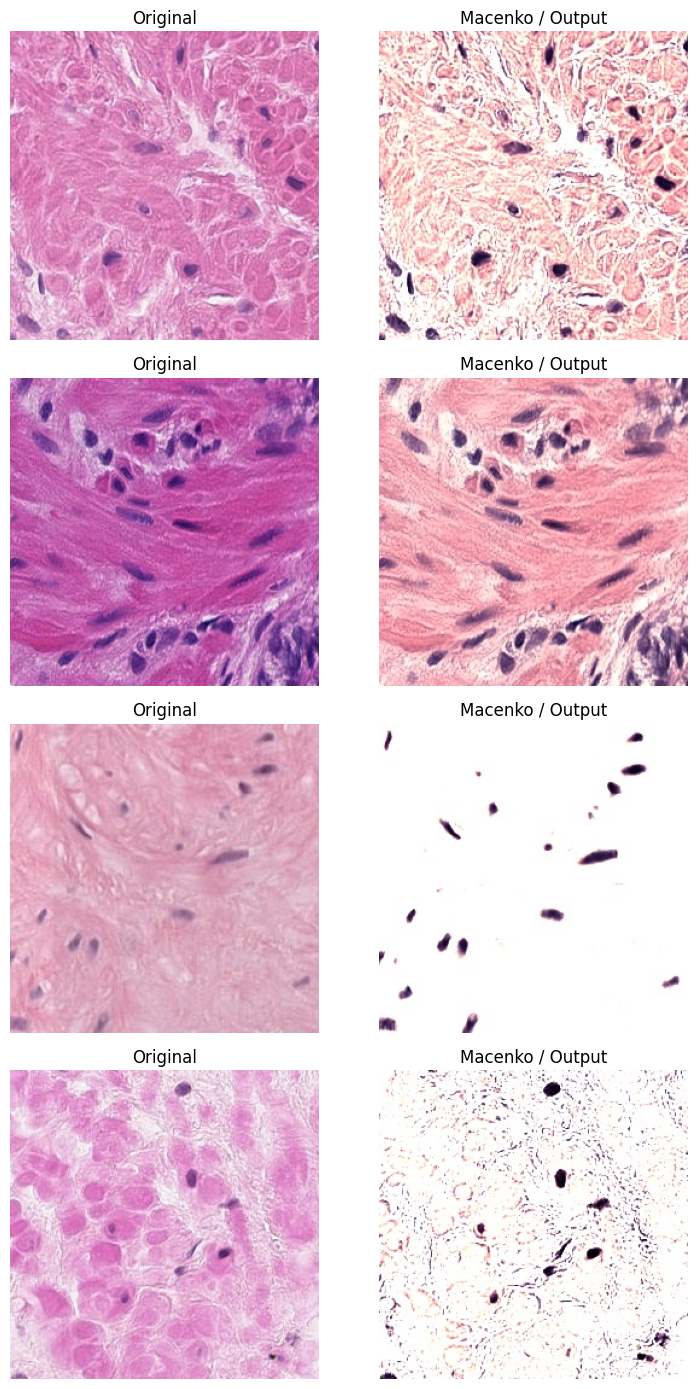

In [16]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_names = random.sample(
    sorted(input_names),
    4
)

fig, axes = plt.subplots(4, 2, figsize=(8, 14))

for row, name in enumerate(sample_names):
    original = np.array(Image.open(IMG_DIR / name).convert("RGB"))
    normalized = np.array(Image.open(NORM_DIR / name).convert("RGB"))

    axes[row, 0].imshow(original)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(normalized)
    axes[row, 1].set_title("Macenko / Output")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [17]:
import zipfile
from pathlib import Path

ZIP_PATH = WORK_DIR / "tiles_norm.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

norm_files = sorted(NORM_DIR.glob("*.jpg"))

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:
    for path in norm_files:
        zf.write(
            path,
            arcname=path.name
        )

print("ZIP created:", ZIP_PATH)
print("ZIP size:", ZIP_PATH.stat().st_size / (1024 ** 2), "MB")
print("Files added:", len(norm_files))

ZIP created: /content/pathoscope_02/tiles_norm.zip
ZIP size: 411.66655254364014 MB
Files added: 12800


In [18]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    names = zf.namelist()
    bad_file = zf.testzip()

print("ZIP files:", len(names))
print("Expected:", 12800)
print("Corrupt file:", bad_file)

if len(names) == 12800 and bad_file is None:
    print("FINAL ZIP CHECK PASSED")
else:
    print("FINAL ZIP CHECK FAILED")

ZIP files: 12800
Expected: 12800
Corrupt file: None
FINAL ZIP CHECK PASSED


In [19]:
import subprocess
import sys

print("Checking C++ compiler...")

result = subprocess.run(
    ["g++", "--version"],
    capture_output=True,
    text=True
)

print(result.stdout.splitlines()[0])

print("\nChecking OpenMP support...")

test_code = r"""
#include <omp.h>
#include <iostream>

int main() {
    std::cout << "OpenMP threads: " << omp_get_max_threads() << std::endl;
    return 0;
}
"""

with open("/content/test_openmp.cpp", "w") as f:
    f.write(test_code)

result = subprocess.run(
    [
        "g++",
        "-fopenmp",
        "/content/test_openmp.cpp",
        "-o",
        "/content/test_openmp"
    ],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    run = subprocess.run(
        ["/content/test_openmp"],
        capture_output=True,
        text=True
    )
    print(run.stdout)
else:
    print("OpenMP compilation failed:")
    print(result.stderr)

Checking C++ compiler...
g++ (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0

Checking OpenMP support...
OpenMP threads: 2



In [20]:
!pip install -q pybind11

import pybind11
print("pybind11 version:", pybind11.__version__)
print("pybind11 include:", pybind11.get_include())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 11.9 MB/s eta 0:00:00
pybind11 version: 3.1.0
pybind11 include: /usr/local/lib/python3.13/dist-packages/pybind11/include


# Step 1 — Create the C++

In [21]:
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("Exists:", WORK_DIR.exists())

WORK_DIR: /content/pathoscope_02
Exists: True


In [22]:
CPP_FILE = Path("/content/pathoscope_02/stainnorm.cpp")

In [23]:
from pathlib import Path
import pybind11
import sysconfig

CPP_FILE = Path("/content/pathoscope_02/stainnorm.cpp")

In [24]:
from pathlib import Path
import os

WORK_DIR = Path("/content/pathoscope_02")
CPP_FILE = WORK_DIR / "stainnorm.cpp"

# Make sure the folder exists
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Check the folder
print("Folder exists:", WORK_DIR.exists())
print("Folder:", WORK_DIR)

# Check whether C++ file already exists
print("Before writing:", CPP_FILE.exists())

# Write a small test first
with open(CPP_FILE, "w", encoding="utf-8") as f:
    f.write("// PathoScope C++ stain normalization core\n")
    f.flush()

os.sync()

print("After writing:", CPP_FILE.exists())
print("File path:", CPP_FILE)
print("File size:", os.path.getsize(CPP_FILE), "bytes")

print("\nFolder contents:")
for item in WORK_DIR.iterdir():
    print(" -", item.name)

Folder exists: True
Folder: /content/pathoscope_02
Before writing: False
After writing: True
File path: /content/pathoscope_02/stainnorm.cpp
File size: 43 bytes

Folder contents:
 - stainnorm.cpp
 - masks
 - tiles_norm
 - ref_stain.npz
 - tiles_norm.zip
 - images


In [25]:
from pathlib import Path

CPP_FILE = Path("/content/pathoscope_02/stainnorm.cpp")

cpp_code = r'''
#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>

#include <algorithm>
#include <cmath>

#ifdef _OPENMP
#include <omp.h>
#endif

namespace py = pybind11;

py::array_t<unsigned char> normalize_tile(
    py::array_t<unsigned char, py::array::c_style | py::array::forcecast> image,
    py::array_t<float, py::array::c_style | py::array::forcecast> stain_matrix,
    py::array_t<float, py::array::c_style | py::array::forcecast> he_ref,
    float max_c_h,
    float max_c_e,
    float Io = 240.0f
) {
    auto img = image.unchecked<3>();
    auto stain = stain_matrix.unchecked<2>();
    auto he = he_ref.unchecked<2>();

    const int h = static_cast<int>(img.shape(0));
    const int w = static_cast<int>(img.shape(1));

    auto output = py::array_t<unsigned char>({h, w, 3});
    auto out = output.mutable_unchecked<3>();

    const float h0 = stain(0, 0);
    const float h1 = stain(1, 0);
    const float h2 = stain(2, 0);

    const float e0 = stain(0, 1);
    const float e1 = stain(1, 1);
    const float e2 = stain(2, 1);

    const float HH = h0*h0 + h1*h1 + h2*h2;
    const float EE = e0*e0 + e1*e1 + e2*e2;
    const float HE = h0*e0 + h1*e1 + h2*e2;

    const float det = HH * EE - HE * HE;
    const float safe_det =
        (std::abs(det) < 1e-8f) ? 1e-8f : det;

    #pragma omp parallel for
    for (int y = 0; y < h; ++y) {

        for (int x = 0; x < w; ++x) {

            float r = static_cast<float>(img(y, x, 0));
            float g = static_cast<float>(img(y, x, 1));
            float b = static_cast<float>(img(y, x, 2));

            float od0 = -std::log((r + 1.0f) / Io);
            float od1 = -std::log((g + 1.0f) / Io);
            float od2 = -std::log((b + 1.0f) / Io);

            float YH = h0*od0 + h1*od1 + h2*od2;
            float YE = e0*od0 + e1*od1 + e2*od2;

            float cH = (EE * YH - HE * YE) / safe_det;
            float cE = (HH * YE - HE * YH) / safe_det;

            cH = std::max(0.0f, cH);
            cE = std::max(0.0f, cE);

            float normalized_h =
                cH / std::max(max_c_h, 1e-6f);

            float normalized_e =
                cE / std::max(max_c_e, 1e-6f);

            float od_out_0 =
                he(0, 0) * normalized_h +
                he(0, 1) * normalized_e;

            float od_out_1 =
                he(1, 0) * normalized_h +
                he(1, 1) * normalized_e;

            float od_out_2 =
                he(2, 0) * normalized_h +
                he(2, 1) * normalized_e;

            float out_r = Io * std::exp(-od_out_0);
            float out_g = Io * std::exp(-od_out_1);
            float out_b = Io * std::exp(-od_out_2);

            out_r = std::min(255.0f, std::max(0.0f, out_r));
            out_g = std::min(255.0f, std::max(0.0f, out_g));
            out_b = std::min(255.0f, std::max(0.0f, out_b));

            out(y, x, 0) =
                static_cast<unsigned char>(out_r);

            out(y, x, 1) =
                static_cast<unsigned char>(out_g);

            out(y, x, 2) =
                static_cast<unsigned char>(out_b);
        }
    }

    return output;
}

PYBIND11_MODULE(stainnorm, m) {

    m.doc() =
        "PathoScope C++ stain normalization core";

    m.def(
        "normalize_tile",
        &normalize_tile,
        "Normalize one RGB tile using Macenko stain vectors"
    );
}
'''

with open(CPP_FILE, "w", encoding="utf-8") as f:
    f.write(cpp_code)

print("C++ source written successfully")
print("Path:", CPP_FILE)
print("Exists:", CPP_FILE.exists())
print("Size:", CPP_FILE.stat().st_size, "bytes")

C++ source written successfully
Path: /content/pathoscope_02/stainnorm.cpp
Exists: True
Size: 3351 bytes


In [26]:
import sysconfig
import pybind11
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")
CPP_FILE = WORK_DIR / "stainnorm.cpp"

PYTHON_INCLUDE = sysconfig.get_paths()["include"]
PYBIND_INCLUDE = pybind11.get_include()

print("Python include:")
print(PYTHON_INCLUDE)

print("\npybind11 include:")
print(PYBIND_INCLUDE)

print("\nCompiling C++ module...")

!g++ -O3 -Wall -shared -std=c++17 -fPIC \
    -fopenmp \
    -I"{PYTHON_INCLUDE}" \
    -I"{PYBIND_INCLUDE}" \
    "{CPP_FILE}" \
    -o "{WORK_DIR}/stainnorm$(python3-config --extension-suffix)"

print("\nCompilation finished.")

print("\nCompiled files:")
for f in WORK_DIR.glob("stainnorm*.so"):
    print(f.name, "-", f.stat().st_size, "bytes")

Python include:
/usr/include/python3.13

pybind11 include:
/usr/local/lib/python3.13/dist-packages/pybind11/include

Compiling C++ module...
/bin/bash: line 1: python3-config: command not found

Compilation finished.

Compiled files:


In [27]:
import sysconfig
import pybind11
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")
CPP_FILE = WORK_DIR / "stainnorm.cpp"

PYTHON_INCLUDE = sysconfig.get_paths()["include"]
PYBIND_INCLUDE = pybind11.get_include()
EXT_SUFFIX = sysconfig.get_config_var("EXT_SUFFIX")

OUTPUT_FILE = WORK_DIR / f"stainnorm{EXT_SUFFIX}"

print("Python include:", PYTHON_INCLUDE)
print("pybind11 include:", PYBIND_INCLUDE)
print("Extension suffix:", EXT_SUFFIX)
print("Output:", OUTPUT_FILE)

print("\nCompiling...")

import subprocess

cmd = [
    "g++",
    "-O3",
    "-Wall",
    "-shared",
    "-std=c++17",
    "-fPIC",
    "-fopenmp",
    f"-I{PYTHON_INCLUDE}",
    f"-I{PYBIND_INCLUDE}",
    str(CPP_FILE),
    "-o",
    str(OUTPUT_FILE)
]

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)

print("\nCompiler return code:", result.returncode)

if result.stdout:
    print("\nCompiler output:")
    print(result.stdout)

if result.stderr:
    print("\nCompiler messages:")
    print(result.stderr)

if result.returncode == 0 and OUTPUT_FILE.exists():
    print("\nC++ COMPILATION SUCCESSFUL")
    print("Module:", OUTPUT_FILE)
    print("Size:", OUTPUT_FILE.stat().st_size, "bytes")
else:
    print("\nC++ COMPILATION FAILED")

Python include: /usr/include/python3.13
pybind11 include: /usr/local/lib/python3.13/dist-packages/pybind11/include
Extension suffix: .cpython-313-x86_64-linux-gnu.so
Output: /content/pathoscope_02/stainnorm.cpython-313-x86_64-linux-gnu.so

Compiling...

Compiler return code: 0

C++ COMPILATION SUCCESSFUL
Module: /content/pathoscope_02/stainnorm.cpython-313-x86_64-linux-gnu.so
Size: 249920 bytes


In [28]:
import sys
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")

# Add the compiled module directory
sys.path.insert(0, str(WORK_DIR))

import stainnorm

print("C++ module imported successfully")
print("Module:", stainnorm)
print("Function:", stainnorm.normalize_tile)

C++ module imported successfully
Module: <module 'stainnorm' from '/content/pathoscope_02/stainnorm.cpython-313-x86_64-linux-gnu.so'>
Function: <built-in method normalize_tile of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7b9eda903990>


In [29]:
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")
IMG_DIR = WORK_DIR / "images"
MASK_DIR = WORK_DIR / "masks"

print("WORK_DIR exists:", WORK_DIR.exists())
print("IMG_DIR exists:", IMG_DIR.exists())
print("MASK_DIR exists:", MASK_DIR.exists())

if IMG_DIR.exists():
    files = list(IMG_DIR.iterdir())
    print("\nImages folder files:", len(files))
    print("First few:", [f.name for f in files[:5]])

if MASK_DIR.exists():
    files = list(MASK_DIR.iterdir())
    print("\nMasks folder files:", len(files))
    print("First few:", [f.name for f in files[:5]])

WORK_DIR exists: True
IMG_DIR exists: True
MASK_DIR exists: True

Images folder files: 12800
First few: ['7a40364bb1370598575caac647f1635f_x5888_y8704.jpg', '8f264374ed3fa427615c1650218e7f21_x2816_y5888.jpg', '33f343b9a016f58f2e78d1b2109ffab9_x12800_y5376.jpg', '16cc34b16c0b30e43e8c33f572440ae6_x768_y7168.jpg', '20b65b9fdf04f2d2d80f515bc939ee7a_x7680_y22784.jpg']

Masks folder files: 12800
First few: ['0d19c87a2ac19e41556441cdfafd7234_x2560_y10752.png', 'ae1c6bd846449adbde74b0cba5cb7a19_x14080_y2560.png', '33f343b9a016f58f2e78d1b2109ffab9_x16896_y12032.png', '87ebd3322722faa0adfc6a3efb9e9bbb_x768_y10752.png', 'fe8b4d94ce299ed485c900f05ae508d3_x20224_y2816.png']


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")

print("DATA_DIR exists:", DATA_DIR.exists())
print("DATA_DIR:", DATA_DIR)

if DATA_DIR.exists():
    print("\nFiles:")
    for f in sorted(DATA_DIR.iterdir()):
        print(f" - {f.name}")

DATA_DIR exists: True
DATA_DIR: /content/drive/MyDrive/PathoScope/data

Files:
 - tiles.csv
 - tiles_img.zip
 - tiles_mask.zip


In [32]:
from pathlib import Path
import zipfile

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")

IMG_ZIP = DATA_DIR / "tiles_img.zip"
MASK_ZIP = DATA_DIR / "tiles_mask.zip"

WORK_DIR = Path("/content/pathoscope_02")
IMG_DIR = WORK_DIR / "images"
MASK_DIR = WORK_DIR / "masks"

IMG_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

print("Extracting image tiles...")

with zipfile.ZipFile(IMG_ZIP, "r") as z:
    z.extractall(IMG_DIR)

print("Image extraction complete.")

print("Extracting mask tiles...")

with zipfile.ZipFile(MASK_ZIP, "r") as z:
    z.extractall(MASK_DIR)

print("Mask extraction complete.")

img_files = list(IMG_DIR.glob("*.jpg"))
mask_files = list(MASK_DIR.glob("*.png"))

print("\nImages:", len(img_files))
print("Masks:", len(mask_files))

assert len(img_files) == 12800
assert len(mask_files) == 12800

print("\nTILE EXTRACTION PASSED")


Extracting image tiles...
Image extraction complete.
Extracting mask tiles...
Mask extraction complete.

Images: 12800
Masks: 12800

TILE EXTRACTION PASSED


In [33]:
import sys
import numpy as np
import cv2
from pathlib import Path

WORK_DIR = Path("/content/pathoscope_02")
IMG_DIR = WORK_DIR / "images"

# Make sure the compiled module can be imported
sys.path.insert(0, str(WORK_DIR))
import stainnorm

# Select one real tile
tile_file = sorted(IMG_DIR.glob("*.jpg"))[0]

img_bgr = cv2.imread(str(tile_file), cv2.IMREAD_COLOR)

if img_bgr is None:
    raise RuntimeError(f"Could not read tile: {tile_file}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Tile:", tile_file.name)
print("Input shape:", img_rgb.shape)
print("Input dtype:", img_rgb.dtype)
print("Input range:", img_rgb.min(), "to", img_rgb.max())

# Same reference stain matrix used in Notebook 02
HE_REF = np.array([
    [0.5626, 0.2159],
    [0.7201, 0.8012],
    [0.4062, 0.5581]
], dtype=np.float32)

# Stain matrix estimated earlier during Notebook 02 testing
stain_matrix = np.array([
    [0.01747745, 0.48131292],
    [0.83453607, 0.73222844],
    [0.55067603, 0.48184995]
], dtype=np.float32)

MAX_C_REF = np.array(
    [1.9705, 1.0308],
    dtype=np.float32
)

# Run the C++ core
cpp_output = stainnorm.normalize_tile(
    np.ascontiguousarray(img_rgb),
    np.ascontiguousarray(stain_matrix),
    np.ascontiguousarray(HE_REF),
    float(MAX_C_REF[0]),
    float(MAX_C_REF[1])
)

cpp_output = np.asarray(cpp_output)

print("\nC++ output:")
print("Shape:", cpp_output.shape)
print("Dtype:", cpp_output.dtype)
print("Range:", cpp_output.min(), "to", cpp_output.max())

# Validate
assert cpp_output.shape == (256, 256, 3)
assert cpp_output.dtype == np.uint8
assert np.isfinite(cpp_output).all()

print("\nC++ SINGLE-TILE TEST PASSED")

Tile: 008069b542b0439ed69b194674051964_x10240_y2048.jpg
Input shape: (256, 256, 3)
Input dtype: uint8
Input range: 17 to 255


TypeError: normalize_tile(): incompatible function arguments. The following argument types are supported:
    1. (arg0: typing.Annotated[numpy.typing.ArrayLike, numpy.uint8], arg1: typing.Annotated[numpy.typing.ArrayLike, numpy.float32], arg2: typing.Annotated[numpy.typing.ArrayLike, numpy.float32], arg3: typing.SupportsFloat | typing.SupportsIndex, arg4: typing.SupportsFloat | typing.SupportsIndex, arg5: typing.SupportsFloat | typing.SupportsIndex) -> numpy.typing.NDArray[numpy.uint8]

Invoked with: array([[[231, 183, 207],
        [225, 180, 203],
        [222, 176, 202],
        ...,
        [120,  68, 114],
        [115,  63, 109],
        [116,  64, 110]],

       [[244, 196, 220],
        [241, 196, 219],
        [235, 191, 214],
        ...,
        [116,  64, 110],
        [117,  65, 111],
        [124,  73, 116]],

       [[246, 198, 220],
        [253, 208, 229],
        [255, 213, 233],
        ...,
        [118,  67, 110],
        [126,  75, 118],
        [138,  87, 128]],


In [ ]:
# Run the C++ core with the required Io parameter

cpp_output = stainnorm.normalize_tile(
    np.ascontiguousarray(img_rgb),
    np.ascontiguousarray(stain_matrix),
    np.ascontiguousarray(HE_REF),
    float(MAX_C_REF[0]),
    float(MAX_C_REF[1]),
    240.0
)

cpp_output = np.asarray(cpp_output)

print("C++ output:")
print("Shape:", cpp_output.shape)
print("Dtype:", cpp_output.dtype)
print("Range:", cpp_output.min(), "to", cpp_output.max())

assert cpp_output.shape == (256, 256, 3)
assert cpp_output.dtype == np.uint8
assert np.isfinite(cpp_output).all()

print("\nC++ SINGLE-TILE TEST PASSED")

In [34]:
import time
import json
import numpy as np

# NumPy implementation of the same fixed stain-normalization calculation
def numpy_normalize_fixed(
    img,
    stain_matrix,
    he_ref,
    max_c_h,
    max_c_e,
    Io=240.0
):
    img_float = img.astype(np.float32)

    od = -np.log((img_float + 1.0) / Io)

    Y = od.reshape(-1, 3).T

    concentrations = np.linalg.lstsq(
        stain_matrix,
        Y,
        rcond=None
    )[0]

    concentrations = np.maximum(
        concentrations,
        0.0
    )

    normalized_h = (
        concentrations[0] /
        max(max_c_h, 1e-6)
    )

    normalized_e = (
        concentrations[1] /
        max(max_c_e, 1e-6)
    )

    normalized_od = (
        he_ref[:, 0, None] * normalized_h[None, :] +
        he_ref[:, 1, None] * normalized_e[None, :]
    )

    normalized = (
        Io *
        np.exp(-normalized_od)
    )

    normalized = np.clip(
        normalized,
        0,
        255
    )

    return normalized.T.reshape(
        img.shape
    ).astype(np.uint8)


# Warm-up
_ = numpy_normalize_fixed(
    img_rgb,
    stain_matrix,
    HE_REF,
    float(MAX_C_REF[0]),
    float(MAX_C_REF[1])
)

_ = stainnorm.normalize_tile(
    np.ascontiguousarray(img_rgb),
    np.ascontiguousarray(stain_matrix),
    np.ascontiguousarray(HE_REF),
    float(MAX_C_REF[0]),
    float(MAX_C_REF[1]),
    240.0
)

# Number of benchmark repetitions
N_RUNS = 30

# Benchmark NumPy
numpy_times = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    numpy_output = numpy_normalize_fixed(
        img_rgb,
        stain_matrix,
        HE_REF,
        float(MAX_C_REF[0]),
        float(MAX_C_REF[1])
    )

    end = time.perf_counter()
    numpy_times.append(end - start)


# Benchmark C++
cpp_times = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    cpp_output = stainnorm.normalize_tile(
        np.ascontiguousarray(img_rgb),
        np.ascontiguousarray(stain_matrix),
        np.ascontiguousarray(HE_REF),
        float(MAX_C_REF[0]),
        float(MAX_C_REF[1]),
        240.0
    )

    end = time.perf_counter()
    cpp_times.append(end - start)


numpy_mean = float(np.mean(numpy_times))
numpy_std = float(np.std(numpy_times))

cpp_mean = float(np.mean(cpp_times))
cpp_std = float(np.std(cpp_times))

speedup = numpy_mean / cpp_mean

print("Benchmark configuration")
print("-----------------------")
print("Tile:", tile_file.name)
print("Tile size:", img_rgb.shape)
print("Runs:", N_RUNS)

print("\nNumPy")
print("Mean:", numpy_mean, "seconds")
print("Std:", numpy_std, "seconds")

print("\nC++ + OpenMP")
print("Mean:", cpp_mean, "seconds")
print("Std:", cpp_std, "seconds")

print("\nSpeedup:")
print(f"{speedup:.3f}x")

# Validate output
assert numpy_output.shape == cpp_output.shape
assert numpy_output.dtype == np.uint8
assert cpp_output.dtype == np.uint8

print("\nBENCHMARK COMPLETED")

Benchmark configuration
-----------------------
Tile: 008069b542b0439ed69b194674051964_x10240_y2048.jpg
Tile size: (256, 256, 3)
Runs: 30

NumPy
Mean: 0.00941362073331978 seconds
Std: 0.0021483812026359722 seconds

C++ + OpenMP
Mean: 0.0055209578333309155 seconds
Std: 0.0018206094921789588 seconds

Speedup:
1.705x

BENCHMARK COMPLETED


In [35]:
import json
from pathlib import Path

BENCHMARK_FILE = Path("/content/pathoscope_02/benchmark_stainnorm.json")

benchmark_results = {
    "task": "Stain normalization",
    "comparison": "C++ + OpenMP vs NumPy",
    "tile": tile_file.name,
    "tile_shape": list(img_rgb.shape),
    "runs": N_RUNS,
    "numpy_mean_seconds": numpy_mean,
    "numpy_std_seconds": numpy_std,
    "cpp_openmp_mean_seconds": cpp_mean,
    "cpp_openmp_std_seconds": cpp_std,
    "speedup": speedup
}

with open(BENCHMARK_FILE, "w") as f:
    json.dump(benchmark_results, f, indent=2)

print("Benchmark JSON saved:")
print(BENCHMARK_FILE)

print("\nContents:")
print(json.dumps(benchmark_results, indent=2))

Benchmark JSON saved:
/content/pathoscope_02/benchmark_stainnorm.json

Contents:
{
  "task": "Stain normalization",
  "comparison": "C++ + OpenMP vs NumPy",
  "tile": "008069b542b0439ed69b194674051964_x10240_y2048.jpg",
  "tile_shape": [
    256,
    256,
    3
  ],
  "runs": 30,
  "numpy_mean_seconds": 0.00941362073331978,
  "numpy_std_seconds": 0.0021483812026359722,
  "cpp_openmp_mean_seconds": 0.0055209578333309155,
  "cpp_openmp_std_seconds": 0.0018206094921789588,
  "speedup": 1.7050702101885706
}


In [36]:
from pathlib import Path
import shutil

WORK_DIR = Path("/content/pathoscope_02")
DRIVE_DIR = Path("/content/drive/MyDrive/PathoScope/data")

files_to_save = [
    WORK_DIR / "tiles_norm.zip",
    WORK_DIR / "ref_stain.npz",
    WORK_DIR / "benchmark_stainnorm.json",
]

print("Saving Notebook 02 outputs...\n")

for src in files_to_save:

    if not src.exists():
        raise FileNotFoundError(f"Missing output: {src}")

    dst = DRIVE_DIR / src.name

    shutil.copy2(src, dst)

    print(f"Saved: {dst.name}")
    print(f"Size: {dst.stat().st_size / (1024**2):.2f} MB\n")

print("NOTEBOOK 02 OUTPUTS SAVED SUCCESSFULLY")

Saving Notebook 02 outputs...

Saved: tiles_norm.zip
Size: 411.67 MB

Saved: ref_stain.npz
Size: 0.00 MB

Saved: benchmark_stainnorm.json
Size: 0.00 MB

NOTEBOOK 02 OUTPUTS SAVED SUCCESSFULLY
